In [1]:
import netCDF4
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import cmocean

%matplotlib widget 

In [2]:
folder = "../data/Level2B_TD"
files = os.listdir(folder)
files.sort()

In [3]:
# fig,ax = plt.subplots(figsize=(20,10))
# for file in files:
#     nc = netCDF4.Dataset(os.path.join(folder, file), mode='r', format='NETCDF4_CLASSIC')
#     z = nc.variables["prho"][:]
#     t = nc.variables["time"][:]
#     d = nc.variables["depth_ref"][:]
#     x,y = np.meshgrid(t, d)
#     c = ax.pcolormesh(x,y,z,cmap='jet', vmin=5, vmax=25)
#     nc.close()
# ax.invert_yaxis()
# fig.colorbar(c, ax=ax)

## 0. Metadata

In [97]:
date_sheets=list(map(str,np.arange(2008,2023,1)))
df = pd.read_excel('../data/meta_data/0_CTD information_2008-2022_ms_221201.xlsx',sheet_name=date_sheets)

In [104]:
meta_date=[]
meta_prof=[]
for date_name in date_sheets:
    if date_name in ['2008','2009']:
        # Add "0":
        dateval=pd.to_datetime('0' + df[date_name][1:].date.astype(int).astype(str),format= "%y%m%d")
    else:
        dateval=pd.to_datetime(df[date_name][1:].date,format= "%y%m%d")   
    meta_date.extend(dateval.tolist()) 
    meta_prof.extend(df[date_name]['Profile count'][1:].tolist()) 
meta_prof=np.array(meta_prof)

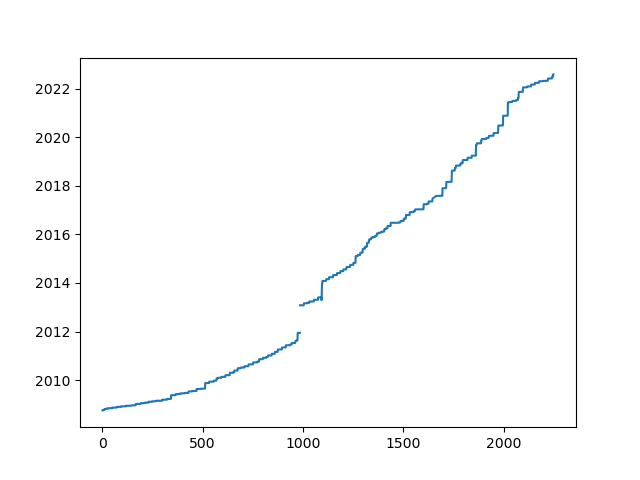

In [107]:
fig,ax=plt.subplots()
ax.plot(meta_prof,meta_date)

## 1. All the profiles

### Combine all the profiles deeper than the main chemocline

In [3]:
first = True
dmin=260
for file in files:
    nc = netCDF4.Dataset(os.path.join(folder, file), mode='r', format='NETCDF4_CLASSIC')
    d = nc.variables["depth_ref"][:] 
    rho = nc.variables["rho"][:]
    indkeep=[]
    # Remove small profiles:
    for kprof in np.arange(0,len(rho[0]),1):
        if np.max(d[np.logical_not(np.isnan(rho[:,kprof]))])>dmin:
            indkeep.append(kprof)                    
    
    rho_keep=rho[:,indkeep]
    if first:
        rho_all = rho_keep
        t_all = nc.variables["time"][indkeep] 
        temp_all = nc.variables["Temp"][:,indkeep]
        cond_all = nc.variables["Cond"][:,indkeep]
        turb_all = nc.variables["Turb"][:,indkeep] 
        pH_all = nc.variables["pH"][:,indkeep]
        DO_all = nc.variables["DO_mg"][:,indkeep]
        d_all = d 
        first = False
    else:
        rho_all = np.concatenate((rho_all, rho_keep), axis=1) 
        t_all = np.concatenate((t_all, nc.variables["time"][:][indkeep]), axis=0)
        temp_all = np.concatenate((temp_all, nc.variables["Temp"][:][:,indkeep]), axis=1) 
        cond_all = np.concatenate((cond_all, nc.variables["Cond"][:][:,indkeep]), axis=1) 
        turb_all = np.concatenate((turb_all, nc.variables["Turb"][:][:,indkeep]), axis=1)
        pH_all = np.concatenate((pH_all, nc.variables["pH"][:][:,indkeep]), axis=1) 
        DO_all = np.concatenate((DO_all, nc.variables["DO_mg"][:][:,indkeep]), axis=1) 
    nc.close()

t_date_all = [datetime.utcfromtimestamp(k) for k in t_all.data]
x,y = np.meshgrid(t_date_all, d_all)


### Figure grid

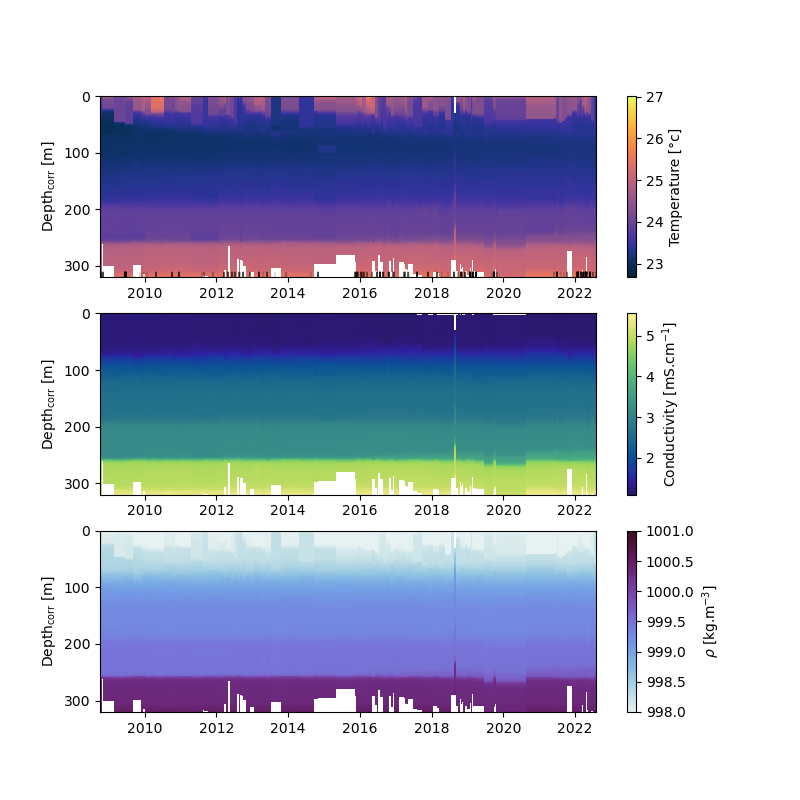

In [4]:
fig,ax = plt.subplots(3,1,figsize=(8,8))

c1 = ax[0].pcolormesh(x,y,temp_all,cmap=cmocean.cm.thermal)
#ax[0].plot(t_date_all,np.full(len(t_date_all),0),'ro',markersize=3)
ylimval=ax[0].get_ylim()
for kprof in np.arange(0,len(t_date_all),1):
            ax[0].plot(np.full(2,t_date_all[kprof]),np.array([ylimval[1]-10,ylimval[1]]),'-k',linewidth=0.2)
ax[0].invert_yaxis()
cb1=fig.colorbar(c1, ax=ax[0])
cb1.set_label('Temperature [°c]')
ax[0].set_ylabel('Depth$_{\\rm corr}$ [m]')

c2 = ax[1].pcolormesh(x,y,cond_all,cmap=cmocean.cm.haline)
ax[1].invert_yaxis()
cb2=fig.colorbar(c2, ax=ax[1])
cb2.set_label('Conductivity [mS.cm$^{-1}$]')
ax[1].set_ylabel('Depth$_{\\rm corr}$ [m]')

c3 = ax[2].pcolormesh(x,y,rho_all,cmap=cmocean.cm.dense,vmin=998,vmax=1001)
#c = ax.pcolor(x,y,rho_all,cmap='jet',vmin=998,vmax=1001)
ax[2].invert_yaxis()
cb3=fig.colorbar(c3, ax=ax[2])
cb3.set_label('$\\rho$ [kg.m$^{-3}$]')
ax[2].set_ylabel('Depth$_{\\rm corr}$ [m]')

fig.savefig("time_series_grid.png")

### Figure for selected profiles

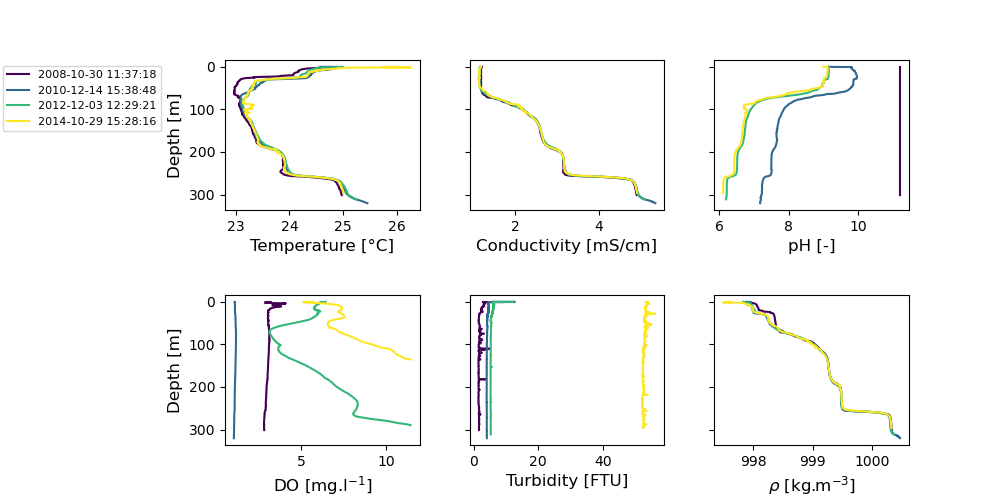

In [6]:
fig,ax = plt.subplots(2,3,figsize=(10,5),sharey=True)
ptemp=[]
dx=0.1 # To shift axes
dy=0.05
# ind_select=[0,70,120,150]
# t_date=[t_date_all[i] for i in ind_select]
date_chosen=[datetime(2009,1,1),datetime(2011,1,1),datetime(2013,1,1),datetime(2015,1,1)] # Choose dates
ind_select=np.full(len(date_chosen),0) 
k=0
for date_val in date_chosen: # Get index of the profile taken the closest from the chosen date
    ind_select[k]=np.argmin(np.abs(np.array(t_date_all)-date_chosen[k]))
    k=k+1
date_select=list(np.array(t_date_all)[ind_select])

Cmap=plt.get_cmap('viridis',len(ind_select))
kprof=0

for indprof in ind_select:
    
    hplot,=ax[0,0].plot(temp_all[:,indprof],d,color=Cmap(kprof))
    ptemp.append(hplot)
    
    if indprof==ind_select[-1]:
        ax[0,0].set_xlabel('Temperature [°C]',fontsize=12)
        ax[0,0].set_ylabel('Depth [m]',fontsize=12)
#         ax[0,0].tick_params(axis='x', labelsize=12)
#         ax[0,0].tick_params(axis='y', labelsize=12)
        ax[0,0].legend(handles=ptemp,labels=date_select,loc='upper right',bbox_to_anchor=(-0.3,1),fontsize=8)
        axpos0=ax[0,0].get_position()
        axpos_new=[axpos0.x0+dx,axpos0.y0+dy,axpos0.width-dx/3,axpos0.height-dy]
        ax[0,0].set_position(axpos_new)
        ax[0,0].invert_yaxis() # Only do it for first y-axis as all the y-axes are linked by sharey option
    
    ax[0,1].plot(cond_all[:,indprof],d,color=Cmap(kprof))
    if indprof==ind_select[-1]:
        ax[0,1].set_xlabel('Conductivity [mS/cm]',fontsize=12)
        ax[0,1].set_position([axpos_new[0]+axpos_new[2]+0.05,axpos_new[1],axpos_new[2],axpos_new[3]])
        #ax[0,1].invert_yaxis()
    
    ax[0,2].plot(pH_all[:,indprof],d,color=Cmap(kprof))
    if indprof==ind_select[-1]:
        ax[0,2].set_xlabel('pH [-]',fontsize=12)
        ax[0,2].set_position([axpos_new[0]+2*axpos_new[2]+2*0.05,axpos_new[1],axpos_new[2],axpos_new[3]])
        #ax[0,2].invert_yaxis()
    
    ax[1,0].plot(DO_all[:,indprof],d,color=Cmap(kprof))
    if indprof==ind_select[-1]:
        ax[1,0].set_xlabel('DO [mg.l$^{-1}$]',fontsize=12)
        ax[1,0].set_ylabel('Depth [m]',fontsize=12)
        axpos1=ax[1,0].get_position()
        ax[1,0].set_position([axpos_new[0],axpos1.y0,axpos_new[2],axpos_new[3]])
        #ax[1,0].invert_yaxis()
    
    ax[1,1].plot(turb_all[:,indprof],d,color=Cmap(kprof))
    if indprof==ind_select[-1]:
        ax[1,1].set_xlabel('Turbidity [FTU]',fontsize=12)
        ax[1,1].set_position([axpos_new[0]+axpos_new[2]+0.05,axpos1.y0,axpos_new[2],axpos_new[3]])
        #ax[1,1].invert_yaxis()
    
    ax[1,2].plot(rho_all[:,indprof],d,color=Cmap(kprof))
    if indprof==ind_select[-1]:
        ax[1,2].set_xlabel('$\\rho$ [kg.m$^{-3}$]',fontsize=12)
        ax[1,2].set_position([axpos_new[0]+2*axpos_new[2]+2*0.05,axpos1.y0,axpos_new[2],axpos_new[3]])
        #ax[1,2].invert_yaxis()
    kprof=kprof+1
    

## 2.Single profile files

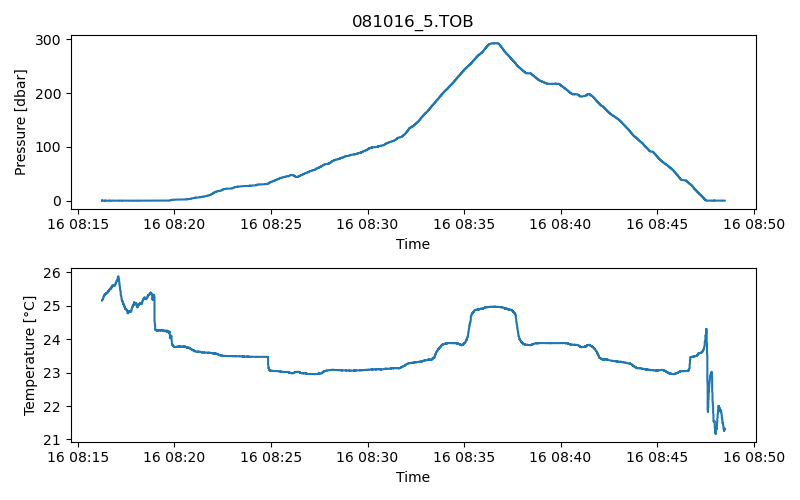

In [3]:
foldername='../data/Level2A_TD/'
# filename_list=(['L2A_20081024_132502.nc','L2A_20081024_134048.nc','L2A_20081024_135905.nc','L2A_20081025_003506.nc',
#                 'L2A_20081025_004315.nc','L2A_20081025_010211.nc'])
filename_list=['L2A_20081016_081615.nc']
for kfile in np.arange(0,len(filename_list),1):
    nc=netCDF4.Dataset(foldername+filename_list[kfile], mode='r', format='NETCDF4_CLASSIC')
    t = nc.variables["time"][:]
    temp = nc.variables["Temp"][:]
    press = nc.variables["Press"][:]
    # print(nc)
    
    
    t_date= [datetime.utcfromtimestamp(k) for k in t.data]
    #t_date= [datetime.fromtimestamp(k) for k in t.data]
    
    fig,ax=plt.subplots(2,1,figsize=(8,5))

    ax[0].plot(t_date,press)
    ax[0].set(xlabel='Time',ylabel='Pressure [dbar]',title=nc.file_name)

#     ax[1].plot(press,temp)
#     ax[1].set(xlabel='Pressure [dbar]',ylabel='Temperature [°C]')
    ax[1].plot(t_date,temp)
    ax[1].set(xlabel='Time',ylabel='Temperature [°C]')
    
    plt.tight_layout()
    
    nc.close

## 3. Profiles from a monthly file

### Open the file

In [7]:
kfile=0
nc=netCDF4.Dataset(os.path.join(folder, files[kfile]), mode='r', format='NETCDF4_CLASSIC')
temp = nc.variables["Temp"][:]
cond = nc.variables["Cond"][:]
turb = nc.variables["Turb"][:]
pH = nc.variables["pH"][:]
DO = nc.variables["DO_mg"][:]
rho = nc.variables["rho"][:]
t = nc.variables["time"][:] 
d = nc.variables["depth_ref"][:]
#print(nc)
nc.close
t_date = [datetime.fromtimestamp(k) for k in t.data]

### Plot one profile from the file

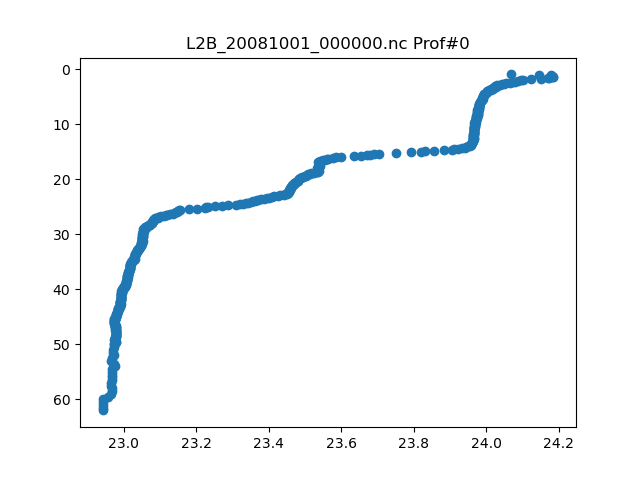

In [8]:
tdata=t.data
#indafter=np.where(t>datetime(2008,10,25,0,0,0).timestamp())[0][0]
indafter=0
tempval=temp[:,indafter].data
fig,ax=plt.subplots()
ax.plot(tempval,d.data,'o')
ax.set_title(files[kfile]+' Prof#'+str(indafter))
ax.invert_yaxis()

### Plot all the profiles from the file

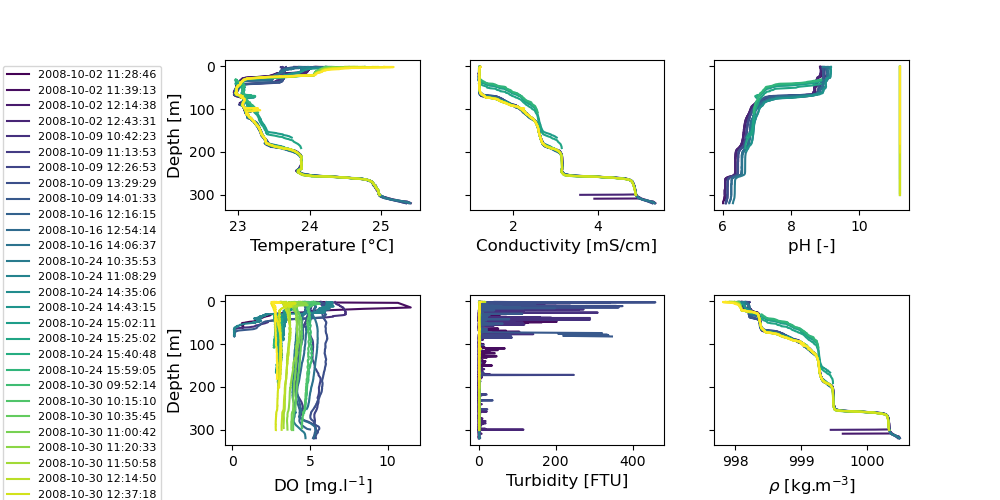

In [9]:
# interactive inline:
#%matplotlib widget 
#separate window:
#%matplotlib qt
fig,ax = plt.subplots(2,3,figsize=(10,5),sharey=True)
ptemp=[]
dx=0.1 # To shift axes
dy=0.05
Cmap=plt.get_cmap('viridis',len(t))

for indprof in np.arange(0,len(t),1):
    
    hplot,=ax[0,0].plot(temp[:,indprof],d,color=Cmap(indprof))
    ptemp.append(hplot)
    
    if indprof==len(t)-1:
        ax[0,0].set_xlabel('Temperature [°C]',fontsize=12)
        ax[0,0].set_ylabel('Depth [m]',fontsize=12)
#         ax[0,0].tick_params(axis='x', labelsize=12)
#         ax[0,0].tick_params(axis='y', labelsize=12)
        ax[0,0].legend(handles=ptemp,labels=t_date,loc='upper right',bbox_to_anchor=(-0.3,1),fontsize=8)
        axpos0=ax[0,0].get_position()
        axpos_new=[axpos0.x0+dx,axpos0.y0+dy,axpos0.width-dx/3,axpos0.height-dy]
        ax[0,0].set_position(axpos_new)
        ax[0,0].invert_yaxis() # Only do it for first y-axis as all the y-axes are linked by sharey option
    
    ax[0,1].plot(cond[:,indprof],d,color=Cmap(indprof))
    if indprof==len(t)-1:
        ax[0,1].set_xlabel('Conductivity [mS/cm]',fontsize=12)
        ax[0,1].set_position([axpos_new[0]+axpos_new[2]+0.05,axpos_new[1],axpos_new[2],axpos_new[3]])
        #ax[0,1].invert_yaxis()
    
    ax[0,2].plot(pH[:,indprof],d,color=Cmap(indprof))
    if indprof==len(t)-1:
        ax[0,2].set_xlabel('pH [-]',fontsize=12)
        ax[0,2].set_position([axpos_new[0]+2*axpos_new[2]+2*0.05,axpos_new[1],axpos_new[2],axpos_new[3]])
        #ax[0,2].invert_yaxis()
    
    ax[1,0].plot(DO[:,indprof],d,color=Cmap(indprof))
    if indprof==len(t)-1:
        ax[1,0].set_xlabel('DO [mg.l$^{-1}$]',fontsize=12)
        ax[1,0].set_ylabel('Depth [m]',fontsize=12)
        axpos1=ax[1,0].get_position()
        ax[1,0].set_position([axpos_new[0],axpos1.y0,axpos_new[2],axpos_new[3]])
        #ax[1,0].invert_yaxis()
    
    ax[1,1].plot(turb[:,indprof],d,color=Cmap(indprof))
    if indprof==len(t)-1:
        ax[1,1].set_xlabel('Turbidity [FTU]',fontsize=12)
        ax[1,1].set_position([axpos_new[0]+axpos_new[2]+0.05,axpos1.y0,axpos_new[2],axpos_new[3]])
        #ax[1,1].invert_yaxis()
    
    ax[1,2].plot(rho[:,indprof],d,color=Cmap(indprof))
    if indprof==len(t)-1:
        ax[1,2].set_xlabel('$\\rho$ [kg.m$^{-3}$]',fontsize=12)
        ax[1,2].set_position([axpos_new[0]+2*axpos_new[2]+2*0.05,axpos1.y0,axpos_new[2],axpos_new[3]])
        #ax[1,2].invert_yaxis()
    